# NPS Prediction Challenge - Artefact
## Sections 4.1 a 4.3

| Section | Entree | Sortie |
|---|---|---|
| 4.1 - Construction du label NPS | Fichiers Excel bruts | `telco_nps_master.csv` |
| 4.2 - Dataset preparation | `telco_nps_master.csv` | `split_data.pkl` |
| 4.3 - Feature engineering | `split_data.pkl` | `split_data.pkl` mis a jour |


In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


---
# Section 4.1 - Construction du Label NPS

## Objectif
Deriver un label NPS (Detracteur / Passif / Promoteur) depuis le `Satisfaction Score` (1-5).

## Data Leakage - Ce qu'on exclut

| Variable | Raison |
|---|---|
| `Churn Value` | L'outcome lui-meme - l'integrer dans le label = predire le churn pas le NPS |
| `Churn Score` | Calcule depuis l'outcome churn |
| `CLTV` | Valeur calculee post-facto |
| `Churn Reason` | Disponible uniquement apres le churn |
| `Churn Category` | Idem |


## Approche

On construit le label NPS en 3 couches :

1. **Mapping direct** : scores clairs (1, 2, 5) — pas d'ambiguite
2. **Regles metier** : scores ambigus (3, 4) enrichis par des signaux comportementaux
3. **Bruit controle** : 10% de flip sur les cas ambigus pour refleter l'incertitude humaine

On compare 3 versions du label :
- `NPS_baseline` : mapping direct recommande par le challenge
- `NPS_enrichi` : mapping + regles metier (version precedente)
- `NPS_enrichi_v2` : mapping + regles metier + bruit controle

In [2]:
# Chargement des fichiers bruts
services = pd.read_excel('/home/johan/Téléchargements/course_ops/nps/artifacts/raw/Telco_customer_churn_services.xlsx')
status   = pd.read_excel('/home/johan/Téléchargements/course_ops/nps/artifacts/raw/Telco_customer_churn_status.xlsx')
location = pd.read_excel('/home/johan/Téléchargements/course_ops/nps/artifacts/raw/Telco_customer_churn_location.xlsx')

status_cols = [
    'Customer ID', 'Satisfaction Score', 'Churn Label',
    'Churn Value', 'Churn Score', 'CLTV',
    'Churn Category', 'Churn Reason', 'Customer Status'
]
services_cols = [
    'Customer ID', 'Referred a Friend', 'Number of Referrals',
    'Tenure in Months', 'Offer', 'Phone Service',
    'Avg Monthly Long Distance Charges', 'Multiple Lines',
    'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Contract',
    'Paperless Billing', 'Payment Method', 'Monthly Charge',
    'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
    'Total Long Distance Charges', 'Total Revenue'
]
location_cols = ['Customer ID', 'City', 'Zip Code', 'Latitude', 'Longitude']

df = (services[services_cols]
      .merge(status[status_cols], on='Customer ID', how='left')
      .merge(location[location_cols], on='Customer ID', how='left'))

print(f'Shape : {df.shape}')
print('\nDistribution Satisfaction Score :')
for score, n in df['Satisfaction Score'].value_counts().sort_index().items():
    print(f'  Score {score} : {n} clients ({n/len(df)*100:.1f}%)')


Shape : (7043, 40)

Distribution Satisfaction Score :
  Score 1 : 922 clients (13.1%)
  Score 2 : 518 clients (7.4%)
  Score 3 : 2665 clients (37.8%)
  Score 4 : 1789 clients (25.4%)
  Score 5 : 1149 clients (16.3%)


---
## Mapping Baseline


In [3]:
df['NPS_baseline'] = df['Satisfaction Score'].map({
    1: 'Detracteur', 2: 'Detracteur', 3: 'Detracteur',
    4: 'Passif',     5: 'Promoteur'
})

print('Distribution NPS Baseline :')
for label in ['Detracteur', 'Passif', 'Promoteur']:
    n = (df['NPS_baseline'] == label).sum()
    print(f'  {label:12s} : {n} ({n/len(df)*100:.1f}%)')


Distribution NPS Baseline :
  Detracteur   : 4105 (58.3%)
  Passif       : 1789 (25.4%)
  Promoteur    : 1149 (16.3%)


---
## Mapping Enrichi - Regles metier

Le score 3 est la zone ambigue (38% du dataset).  
On le discrimine avec le tenure et les referrals :

| Condition | Label | Justification |
|---|---|---|
| Score 1 | Detracteur | Clairement insatisfait |
| Score 2 + tenure <= 36 | Detracteur | Insatisfait, pas encore ancre |
| Score 2 + tenure > 36 | Passif | Tres ancien, insatisfaction peut-etre passagere |
| Score 3 + tenure < 12 | Detracteur | Nouveau + insatisfait = risque immediat |
| Score 3 + tenure >= 12 | Passif | Reste malgre insatisfaction = moins urgent |
| Score 4 + referrals > 0 | Promoteur | Recommande activement = comportement promoteur |
| Score 4 | Passif | Neutre |
| Score 5 | Promoteur | Clairement satisfait |


In [4]:
def build_nps_enrichi(row):
    score     = row['Satisfaction Score']
    tenure    = row['Tenure in Months']
    referrals = row['Number of Referrals']

    if score == 1:
        return 'Detracteur'
    elif score == 2:
        return 'Passif' if tenure > 36 else 'Detracteur'
    elif score == 3:
        return 'Detracteur' if tenure < 12 else 'Passif'
    elif score == 4:
        return 'Promoteur' if referrals > 0 else 'Passif'
    else:
        return 'Promoteur'

df['NPS_enrichi'] = df.apply(build_nps_enrichi, axis=1)

print('Distribution NPS Enrichi :')
for label in ['Detracteur', 'Passif', 'Promoteur']:
    n = (df['NPS_enrichi'] == label).sum()
    print(f'  {label:12s} : {n} ({n/len(df)*100:.1f}%)')


Distribution NPS Enrichi :
  Detracteur   : 1986 (28.2%)
  Passif       : 3004 (42.7%)
  Promoteur    : 2053 (29.1%)


---
## Mapping Enrichi v2 - Regles metier + Bruit controle

On introduit 10% de bruit sur les cas ambigus (score 3 uniquement).  
Cela reflete l'incertitude humaine dans les reponses au sondage.  
Seed fixe -> reproductible.


In [5]:
NOISE_RATE = 0.10

df['NPS_enrichi_v2'] = df['NPS_enrichi'].copy()

idx_score3 = df[df['Satisfaction Score'] == 3].index
n_flip     = int(len(idx_score3) * NOISE_RATE)
idx_flip   = np.random.choice(idx_score3, size=n_flip, replace=False)

def flip_label(label):
    if label == 'Detracteur': return 'Passif'
    if label == 'Passif':     return 'Detracteur'
    return label

df.loc[idx_flip, 'NPS_enrichi_v2'] = df.loc[idx_flip, 'NPS_enrichi_v2'].apply(flip_label)

print(f'Clients score 3 flippes : {n_flip} ({NOISE_RATE*100:.0f}%)')
print('\nDistribution NPS Enrichi v2 :')
for label in ['Detracteur', 'Passif', 'Promoteur']:
    n = (df['NPS_enrichi_v2'] == label).sum()
    print(f'  {label:12s} : {n} ({n/len(df)*100:.1f}%)')


Clients score 3 flippes : 266 (10%)

Distribution NPS Enrichi v2 :
  Detracteur   : 2114 (30.0%)
  Passif       : 2876 (40.8%)
  Promoteur    : 2053 (29.1%)


---
## Validation a posteriori

Croisement avec `Churn Label` (non utilise dans la construction).  
Plus le gradient Detracteur -> Promoteur est marque, plus le label est discriminant.


In [6]:
order = ['Detracteur', 'Passif', 'Promoteur']

print('=== Taux de churn par segment (validation) ===')
for col in ['NPS_baseline', 'NPS_enrichi', 'NPS_enrichi_v2']:
    cross = pd.crosstab(df[col], df['Churn Label'], normalize='index').round(3).reindex(order)
    det  = cross.loc['Detracteur', 'Yes'] if 'Yes' in cross.columns else 0
    pas  = cross.loc['Passif',     'Yes'] if 'Yes' in cross.columns else 0
    prom = cross.loc['Promoteur',  'Yes'] if 'Yes' in cross.columns else 0
    print(f'{col} : Det={det:.1%} | Passif={pas:.1%} | Prom={prom:.1%} | Gradient={det-prom:.1%}')


=== Taux de churn par segment (validation) ===
NPS_baseline : Det=45.5% | Passif=0.0% | Prom=0.0% | Gradient=45.5%
NPS_enrichi : Det=79.7% | Passif=9.5% | Prom=0.0% | Gradient=79.7%
NPS_enrichi_v2 : Det=74.4% | Passif=10.3% | Prom=0.0% | Gradient=74.4%


In [7]:
df['NPS_label'] = df['NPS_enrichi_v2']

print('=== Label final : NPS_enrichi_v2 ===')
for label in ['Detracteur', 'Passif', 'Promoteur']:
    n = (df['NPS_label'] == label).sum()
    print(f'  {label:12s} : {n} ({n/len(df)*100:.1f}%)')

df.to_csv('telco_nps_master.csv', index=False)
print('\nSauvegarde : telco_nps_master.csv')


=== Label final : NPS_enrichi_v2 ===
  Detracteur   : 2114 (30.0%)
  Passif       : 2876 (40.8%)
  Promoteur    : 2053 (29.1%)

Sauvegarde : telco_nps_master.csv


---
---
# Section 4.2 - Dataset Preparation

**Entree :** `telco_nps_master.csv`  
**Sortie :** `split_data.pkl`

## Schema - Ce qu'on exclut

| Categorie | Colonnes |
|---|---|
| Leakage | Churn Score, Churn Value, CLTV |
| Post-churn | Churn Reason, Churn Category |
| Labels intermediaires | NPS_baseline, NPS_enrichi, NPS_enrichi_v2 |
| Identifiant | Customer ID |
| Target | NPS_label |
| Validation uniquement | Churn Label, Customer Status |


In [8]:
df = pd.read_csv('telco_nps_master.csv')
print(f'Dataset charge : {df.shape}')


Dataset charge : (7043, 44)


In [9]:
EXCLUDE_COLS = [
    'Customer ID', 'Satisfaction Score',
    'NPS_baseline', 'NPS_enrichi', 'NPS_enrichi_v2', 'NPS_label',
    'Churn Score', 'Churn Value', 'CLTV',
    'Churn Reason', 'Churn Category',
    'Churn Label', 'Customer Status',
]

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'Features retenues : {len(feature_cols)}')


Features retenues : 31


---
## Valeurs manquantes - Imputation semantique


In [10]:
missing = df[feature_cols].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Valeurs manquantes :')
for col, n in missing.items():
    print(f'  {col:45s} : {n} ({n/len(df)*100:.1f}%)')

df['Offer']        = df['Offer'].fillna('No Offer')
df['Internet Type'] = df['Internet Type'].fillna('No Internet')
df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)

print(f'\nManquants restants : {df[feature_cols].isnull().sum().sum()}')


Valeurs manquantes :
  Offer                                         : 3877 (55.0%)
  Internet Type                                 : 1526 (21.7%)

Manquants restants : 0


---
## Encodage categoriel


In [11]:
cat_cols = df[feature_cols].select_dtypes(include='object').columns.tolist()
num_cols = df[feature_cols].select_dtypes(exclude='object').columns.tolist()

print(f'Variables categorielles : {len(cat_cols)}')
print(f'Variables numeriques    : {len(num_cols)}')

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print('Encodage OK')


Variables categorielles : 18
Variables numeriques    : 13
Encodage OK


---
## Split 15% / 85%

**Train (15%)** : simule les repondants au sondage  
**Test  (85%)** : simule les clients silencieux a predire  

Un split 80/20 classique ne refleterait pas le vrai probleme business.


In [12]:
X = df[feature_cols]
y = df['NPS_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.85, stratify=y, random_state=RANDOM_SEED
)

print(f'Train : {X_train.shape[0]} clients (15%)')
print(f'Test  : {X_test.shape[0]} clients (85%)')

print('\nDistribution train :')
for label in ['Detracteur', 'Passif', 'Promoteur']:
    n = (y_train == label).sum()
    print(f'  {label:12s} : {n} ({n/len(y_train)*100:.1f}%)')


Train : 1056 clients (15%)
Test  : 5987 clients (85%)

Distribution train :
  Detracteur   : 317 (30.0%)
  Passif       : 431 (40.8%)
  Promoteur    : 308 (29.2%)


---
## Desequilibre des classes

Si on predit toujours la classe majoritaire :  
on obtient une accuracy elevee sans rien apprendre.  

On utilisera en section 4.5 : **Macro F1**, **Recall Detracteur**, **QWK**  
et `class_weight='balanced'` dans les modeles.


In [13]:
counts    = y_train.value_counts().reindex(['Detracteur', 'Passif', 'Promoteur'])
dummy_acc = counts.max() / len(y_train)

print('=== Desequilibre (train) ===')
for label, n in counts.items():
    print(f'  {label:12s} : {n} ({n/len(y_train)*100:.1f}%)')
print(f'\nAccuracy modele naif : {dummy_acc:.1%} -> metrique trompeuse')

joblib.dump({
    'X_train'     : X_train,
    'X_test'      : X_test,
    'y_train'     : y_train,
    'y_test'      : y_test,
    'feature_cols': feature_cols,
    'encoders'    : encoders,
}, 'split_data.pkl')
print('\nSauvegarde : split_data.pkl')


=== Desequilibre (train) ===
  Detracteur   : 317 (30.0%)
  Passif       : 431 (40.8%)
  Promoteur    : 308 (29.2%)

Accuracy modele naif : 40.8% -> metrique trompeuse

Sauvegarde : split_data.pkl


---
---
# Section 4.3 - Feature Engineering

**Entree :** `split_data.pkl`  
**Sortie :** `split_data.pkl` mis a jour

## Features construites

| Groupe | Feature | Hypothese business |
|---|---|---|
| Contractuel | `tenure_x_contract` | Anciennete x engagement contractuel |
| Financier | `charge_per_service` | Cout percu par service |
| Financier | `refund_rate` | Incidents et litiges |
| Financier | `monthly_charge_ratio` | Effort financier recent |
| Bundle | `has_security` | Besoin de protection |
| Bundle | `has_streaming` | Usage entertainment |
| Digital | `digital_engagement` | Autonomie digitale |
| Social | `has_referred` | Comportement promoteur direct |

## Ce qu'on ne fait pas

| Element | Raison |
|---|---|
| Features geo complexes | Scope trop large, gain non garanti |
| Toutes les interactions | LightGBM les gere nativement |
| Normalisation | Inutile pour les modeles a base d'arbres |


In [14]:
data         = joblib.load('split_data.pkl')
X_train      = data['X_train'].copy()
X_test       = data['X_test'].copy()
y_train      = data['y_train']
y_test       = data['y_test']
feature_cols = list(data['feature_cols'])
encoders     = data['encoders']

print(f'Features actuelles : {len(feature_cols)}')
print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')


Features actuelles : 31
Train : 1056 | Test : 5987


In [15]:
def add_all_features(X):
    X = X.copy()

    # Groupe 0 - nb_services (base pour les features financieres)
    service_cols = ['Online Security','Online Backup','Device Protection Plan',
                    'Premium Tech Support','Streaming TV','Streaming Movies',
                    'Streaming Music','Multiple Lines']
    X['nb_services'] = X[service_cols].sum(axis=1)

    # Groupe 1 - Contractuel
    X['tenure_x_contract']   = X['Tenure in Months'] * (X['Contract'] + 1)

    # Groupe 2 - Financier
    X['charge_per_service']  = X['Monthly Charge'] / (X['nb_services'] + 1)
    X['refund_rate']         = X['Total Refunds'] / (X['Total Revenue'] + 1)
    X['monthly_charge_ratio']= X['Monthly Charge'] / (X['Tenure in Months'] + 1)

    # Groupe 3 - Bundle
    X['has_security']        = X['Online Security'] + X['Device Protection Plan']
    X['has_streaming']       = X['Streaming TV'] + X['Streaming Movies']

    # Groupe 4 - Digital
    X['digital_engagement']  = X['Paperless Billing'] + X['Payment Method']

    # Groupe 5 - Social
    X['has_referred']        = (X['Number of Referrals'] > 0).astype(int)

    return X

X_train = add_all_features(X_train)
X_test  = add_all_features(X_test)

NEW_FEATURES = [
    'nb_services',
    'tenure_x_contract',
    'charge_per_service', 'refund_rate', 'monthly_charge_ratio',
    'has_security', 'has_streaming',
    'digital_engagement',
    'has_referred',
]

feature_cols_updated = feature_cols + NEW_FEATURES

print(f'Features originales  : {len(feature_cols)}')
print(f'Features construites : {len(NEW_FEATURES)}')
print(f'Total               : {len(feature_cols_updated)}')


Features originales  : 31
Features construites : 9
Total               : 40


In [16]:
print('=== Moyenne par segment NPS (train) ===')
summary = pd.concat([X_train[NEW_FEATURES], y_train], axis=1)
print(summary.groupby('NPS_label')[NEW_FEATURES].mean().round(3).T.to_string())


=== Moyenne par segment NPS (train) ===
NPS_label             Detracteur  Passif  Promoteur
nb_services                2.079   3.320      2.721
tenure_x_contract         22.732  90.626     88.825
charge_per_service        26.077  18.505     18.272
refund_rate                0.002   0.001      0.001
monthly_charge_ratio      11.401   3.467      3.360
has_security               0.445   0.854      0.516
has_streaming              0.647   0.814      0.760
digital_engagement         1.161   1.012      1.071
has_referred               0.328   0.411      0.701


In [17]:
joblib.dump({
    'X_train'             : X_train,
    'X_test'              : X_test,
    'y_train'             : y_train,
    'y_test'              : y_test,
    'feature_cols'        : feature_cols,
    'feature_cols_updated': feature_cols_updated,
    'new_features'        : NEW_FEATURES,
    'encoders'            : encoders,
}, 'split_data.pkl')

print('Sauvegarde : split_data.pkl mis a jour')
print('Prochaine etape : Section 4.4 - Verbatims synthetiques')


Sauvegarde : split_data.pkl mis a jour
Prochaine etape : Section 4.4 - Verbatims synthetiques


---
---
# Section 4.4 - Verbatims Synthetiques

**Entree :** `split_data.pkl`  
**Sortie :** `telco_nps_verbatims.csv` + `split_data.pkl` mis a jour

## Objectif

Generer un verbatim synthetique par client simulant sa derniere interaction  
avec le support client, puis extraire un signal sentiment pour enrichir le modele.

## Pourquoi cette section est importante

Dans un vrai operateur telecom, les verbatims (appels, chats, avis) sont  
la source de signal NPS la plus riche — mais rarement exploitee.  
On teste ici si le texte apporte un signal complementaire aux donnees tabulaires.

## Choix technique : Ollama + Llama 3 (local)

- **Zéro coût**, pas de quota API
- **Reproductible** avec seed fixe
- **Pas de dependance externe** — tout tourne en local
- Qualite suffisante pour du texte court (1-3 phrases)

## Prompt stocke pour reproductibilite

Le prompt exact utilise est documente ci-dessous et sauvegarde avec les donnees.


In [18]:
import joblib
import pandas as pd
import numpy as np
import requests
import json
import time
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Chargement du split
data              = joblib.load('split_data.pkl')
X_train           = data['X_train'].copy()
X_test            = data['X_test'].copy()
y_train           = data['y_train']
y_test            = data['y_test']
feature_cols      = data['feature_cols']
feature_cols_upd  = data['feature_cols_updated']
new_features      = data['new_features']
encoders          = data['encoders']

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')


Train : 1056 | Test : 5987


---
## Etape 1 - Generation des verbatims via Ollama (Llama 3)

### Prompt utilise

```
Tu es un client d'un operateur telecom.
Profil : {nps_label}, {tenure} mois d'anciennete, contrat {contract},
{nb_services} services, {monthly_charge} USD/mois.
Ecris en 1-3 phrases ce que tu as dit lors de ton dernier contact support.
Sois realiste. Ne mentionne pas ton score NPS explicitement.
```

### Bruit controle (15%)

Pour 15% des clients, on inverse le ton attendu  
(un Detracteur qui semble satisfait, un Promoteur qui se plaint)  
pour refleter la realite : la correlation texte/NPS est imparfaite.


In [19]:
# Prompt template - stocke pour reproductibilite
PROMPT_TEMPLATE = """You are a customer of an African telecom operator.
Customer profile :
- Satisfaction level : {nps_label}
- Tenure : {tenure} months
- Contract type : {contract}
- Number of services subscribed : {nb_services}
- Monthly charge : {monthly_charge:.0f} USD

Write 1 to 3 short sentences about what this customer said or wrote
during their last contact with customer support.
Expected tone : {ton}
Be realistic and natural. Do not mention any NPS score.
Reponds uniquement avec le verbatim, sans introduction."""

# Mapping contract encode -> lisible
contract_map = {0: 'monthly', 1: 'one year', 2: 'two years'}

# Ton par label NPS
ton_map = {
    'Detracteur': 'frustrated, dissatisfied, unresolved issue',
    'Passif'    : 'neutral, neither positive nor negative',
    'Promoteur' : 'enthusiastic, satisfied, recommends the service'
}

# Ton inverse pour le bruit (15% des cas)
ton_inverse_map = {
    'Detracteur': 'somewhat satisfied despite minor issues',
    'Passif'    : 'slightly positive or slightly negative',
    'Promoteur' : 'slightly disappointed about one specific point'
}

print('Prompt template defini et stocke.')
print(f'\nExemple pour un Detracteur :')
print(PROMPT_TEMPLATE.format(
    nps_label='Detracteur', tenure=3, contract='mensuel',
    nb_services=1, monthly_charge=75.0,
    ton=ton_map['Detracteur']
))


Prompt template defini et stocke.

Exemple pour un Detracteur :
You are a customer of an African telecom operator.
Customer profile :
- Satisfaction level : Detracteur
- Tenure : 3 months
- Contract type : mensuel
- Number of services subscribed : 1
- Monthly charge : 75 USD

Write 1 to 3 short sentences about what this customer said or wrote
during their last contact with customer support.
Expected tone : frustrated, dissatisfied, unresolved issue
Be realistic and natural. Do not mention any NPS score.
Reponds uniquement avec le verbatim, sans introduction.


In [20]:
def generate_verbatim(nps_label, tenure, contract_encoded, nb_services, monthly_charge, noisy=False):
    contract = contract_map.get(int(contract_encoded), 'mensuel')
    ton      = ton_inverse_map[nps_label] if noisy else ton_map[nps_label]

    prompt = PROMPT_TEMPLATE.format(
        nps_label=nps_label, tenure=int(tenure),
        contract=contract, nb_services=int(nb_services),
        monthly_charge=monthly_charge, ton=ton
    )

    try:
        response = requests.post(
            'http://localhost:11434/api/generate',
            json={'model': 'llama3', 'prompt': prompt, 'stream': False},
            timeout=30
        )
        return response.json().get('response', '').strip()
    except Exception as e:
        return f'[Erreur generation : {e}]'

# Test sur 1 client avant de lancer le batch
test_verbatim = generate_verbatim(
    nps_label='Detracteur', tenure=3,
    contract_encoded=0, nb_services=1,
    monthly_charge=75.0, noisy=False
)
print('Test generation OK :')
print(test_verbatim)


Test generation OK :
"I've been trying to get a simple issue resolved for weeks now and I'm still waiting on someone to fix it. Your team keeps telling me to reset my password or reboot my phone, but that's not the problem! Can't you just send someone out to take a look at this?"


In [21]:
# Generation sur tous les clients (train + test)
# On combine pour generer sur la base complete
# Strategie : echantillon stratifie 500 clients
# Raison : generation LLM locale ~7s/client = 14h sur 7043 clients
# En production : pipeline cloud sur la base complete
X_all = pd.concat([X_train, X_test], axis=0)
y_all = pd.concat([y_train, y_test], axis=0)

# Echantillon stratifie 500 clients (proportion NPS preservee)
np.random.seed(RANDOM_SEED)
N_SAMPLE  = 500
parts     = []
for label in ['Detracteur', 'Passif', 'Promoteur']:
    label_idx = y_all[y_all == label].index
    n = max(1, int(N_SAMPLE * len(label_idx) / len(y_all)))
    chosen = np.random.choice(label_idx, size=n, replace=False)
    parts.append(pd.Series(label, index=chosen))
y_sample = pd.concat(parts)
X_sample = X_all.loc[y_sample.index]

print(f'Base complete  : {len(X_all)} clients')
print(f'Echantillon    : {len(X_sample)} clients (stratifie)')
print(f'Distribution :\n{y_sample.value_counts()}')

# Indices bruites 15%
n_noisy   = int(len(X_sample) * 0.15)
idx_noisy = set(np.random.choice(X_sample.index, size=n_noisy, replace=False))

print(f'\nDebut generation sur {len(X_sample)} clients...')
verbatims = []
for i, (idx, row) in enumerate(X_sample.iterrows()):
    nps_label = y_sample[idx]
    noisy     = idx in idx_noisy

    verbatim  = generate_verbatim(
        nps_label        = nps_label,
        tenure           = row['Tenure in Months'],
        contract_encoded = row['Contract'],
        nb_services      = row.get('nb_services', 2),
        monthly_charge   = row['Monthly Charge'],
        noisy            = noisy
    )
    verbatims.append({
        'index'    : idx,
        'NPS_label': nps_label,
        'noisy'    : noisy,
        'verbatim' : verbatim
    })
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(X_sample)} generes...')

df_verbatims = pd.DataFrame(verbatims).set_index('index')
df_verbatims.to_csv('telco_nps_verbatims.csv')
print(f'\nGeneration terminee : {len(df_verbatims)} verbatims')
print('Sauvegarde : telco_nps_verbatims.csv')


Base complete  : 7043 clients
Echantillon    : 499 clients (stratifie)
Distribution :
Passif        204
Detracteur    150
Promoteur     145
Name: count, dtype: int64

Debut generation sur 499 clients...
  50/499 generes...
  100/499 generes...
  150/499 generes...
  200/499 generes...
  250/499 generes...
  300/499 generes...
  350/499 generes...
  400/499 generes...
  450/499 generes...

Generation terminee : 499 verbatims
Sauvegarde : telco_nps_verbatims.csv


---
## Etape 2 - Extraction du Sentiment (VADER)

On utilise VADER (Valence Aware Dictionary and sEntiment Reasoner).  
C'est un analyseur de sentiment base sur des regles, rapide et interpretable.  

Il retourne un score **compound** entre -1 (tres negatif) et +1 (tres positif).  

**Pourquoi VADER et pas des embeddings ?**  
VADER est transparent, sans dependance lourde, et donne un score directement  
integrable comme feature numerique dans LightGBM.  
Les embeddings (sentence-transformers) seraient plus riches mais ajoutent  
une complexite non justifiee ici — on le documente comme next step.


In [22]:
analyzer = SentimentIntensityAnalyzer()

df_verbatims['sentiment_score'] = df_verbatims['verbatim'].apply(
    lambda text: analyzer.polarity_scores(str(text))['compound']
)

print('=== Sentiment moyen par segment NPS ===')
print(df_verbatims.groupby('NPS_label')['sentiment_score'].mean().round(3))

print('\n=== Distribution sentiment ===')
print(df_verbatims.groupby('NPS_label')['sentiment_score'].describe().round(3))


=== Sentiment moyen par segment NPS ===
NPS_label
Detracteur   -0.078
Passif        0.011
Promoteur     0.568
Name: sentiment_score, dtype: float64

=== Distribution sentiment ===
            count   mean    std    min    25%    50%    75%    max
NPS_label                                                         
Detracteur  150.0 -0.078  0.517 -0.926 -0.507 -0.130  0.360  0.861
Passif      204.0  0.011  0.385 -0.765 -0.290  0.000  0.318  0.934
Promoteur   145.0  0.568  0.469 -0.736  0.000  0.833  0.924  0.974


In [23]:
# Exemples de verbatims generes
print('=== Exemples par segment ===')
for label in ['Detracteur', 'Passif', 'Promoteur']:
    sample = df_verbatims[df_verbatims['NPS_label'] == label].iloc[0]
    print(f'\n{label} (noisy={sample["noisy"]}, sentiment={sample["sentiment_score"]:.2f}) :')
    print(f'  {sample["verbatim"][:200]}')


=== Exemples par segment ===

Detracteur (noisy=False, sentiment=-0.36) :
  "I've been trying to get a working SIM card for weeks now and your team just keeps passing the buck. I'm still waiting for someone to fix this issue and it's getting ridiculous."

Passif (noisy=False, sentiment=0.00) :
  "I'm just wondering if there's a way to get some extra data for my phone plan without having to upgrade to a new package."

Promoteur (noisy=True, sentiment=-0.74) :
  "I'm really happy with the overall service, but I'm a bit frustrated that my data speed has been slow lately. I've tried restarting my phone and everything, but it's still not as good as it was when I


---
## Etape 3 - Integration au modele

On ajoute `sentiment_score` comme feature supplementaire  
dans X_train et X_test.

La comparaison des metriques avec et sans cette feature  
se fera en section 4.5 apres l'entrainement du modele.


In [25]:
# Ajout du sentiment score dans X_train et X_test
#X_train['sentiment_score'] = df_verbatims.loc[X_train.index, 'sentiment_score'].values
#X_test['sentiment_score']  = df_verbatims.loc[X_test.index,  'sentiment_score'].values

sentiment_map = df_verbatims['sentiment_score']

# Clients avec verbatim → score réel
# Clients sans verbatim → 0 (neutre, imputation documentée)
X_train['sentiment_score'] = X_train.index.map(sentiment_map).fillna(0)
X_test['sentiment_score']  = X_test.index.map(sentiment_map).fillna(0)

# Mise a jour des listes de features
feature_cols_upd_with_sentiment = feature_cols_upd + ['sentiment_score']

print(f'Feature ajoutee : sentiment_score')
print(f'Total features  : {len(feature_cols_upd_with_sentiment)}')
print(f'\nSentiment moyen train :')
print(pd.concat([X_train[['sentiment_score']], y_train], axis=1)
      .groupby('NPS_label')['sentiment_score'].mean().round(3))




Feature ajoutee : sentiment_score
Total features  : 41

Sentiment moyen train :
NPS_label
Detracteur   -0.003
Passif       -0.002
Promoteur     0.038
Name: sentiment_score, dtype: float64


In [26]:
# Sauvegarde du prompt pour reproductibilite
with open('verbatim_prompt.txt', 'w') as f:
    f.write(PROMPT_TEMPLATE)

# Sauvegarde du split mis a jour
joblib.dump({
    'X_train'                       : X_train,
    'X_test'                        : X_test,
    'y_train'                       : y_train,
    'y_test'                        : y_test,
    'feature_cols'                  : feature_cols,
    'feature_cols_updated'          : feature_cols_upd,
    'feature_cols_with_sentiment'   : feature_cols_upd_with_sentiment,
    'new_features'                  : new_features,
    'encoders'                      : encoders,
}, 'split_data.pkl')

print('Sauvegardes :')
print('  telco_nps_verbatims.csv          : verbatims + sentiment scores')
print('  verbatim_prompt.txt              : prompt utilise (reproductibilite)')
print('  split_data.pkl                   : split mis a jour avec sentiment_score')
print('\nProchaine etape : Section 4.5 - Modelisation')


Sauvegardes :
  telco_nps_verbatims.csv          : verbatims + sentiment scores
  verbatim_prompt.txt              : prompt utilise (reproductibilite)
  split_data.pkl                   : split mis a jour avec sentiment_score

Prochaine etape : Section 4.5 - Modelisation


---
---
# Section 4.5 - Modelisation et Evaluation

**Entree :** `split_data.pkl`  
**Sortie :** `nps_model_final.pkl`

## Strategie

On entraine 4 modeles dans l'ordre de complexite croissante :

| Modele | Role | Justification |
|---|---|---|
| Dummy Classifier | Plancher absolu | Reference naive |
| Regression Logistique | Baseline lineaire | Rapide, interpretable |
| Regression Ordinale | Respecte l'ordre NPS | NPS = cible ordinale |
| LightGBM | Modele final | Performance + interpretabilite SHAP |

## Metriques choisies

| Metrique | Priorite | Justification |
|---|---|---|
| **Recall Detracteur** | 1 | Metrique business : vrais Detracteurs captures |
| **Macro F1** | 2 | Performance equilibree sur les 3 classes |
| **QWK** | 3 | Penalise les erreurs selon leur distance ordinale |
| Calibration | 4 | Probabilites fiables pour le threshold tuning |
| Lift curve | 5 | Utile pour l'equipe retention avec budget limite |

## Pourquoi pas l'accuracy ?

Un modele qui predit toujours Detracteur aurait ~58% d'accuracy sans rien apprendre.  
L'accuracy est une metrique trompeuse sur des cibles desequilibrees.


In [28]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, cohen_kappa_score,
    f1_score, recall_score, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
!pip install lightgbm
import lightgbm as lgb
!pip install mord
import mord

RANDOM_SEED = 42
ORDER       = ['Detracteur', 'Passif', 'Promoteur']

# Chargement du split
data             = joblib.load('split_data.pkl')
X_train          = data['X_train']
X_test           = data['X_test']
y_train          = data['y_train']
y_test           = data['y_test']
feature_cols_upd = data['feature_cols_updated']

# Encodage ordinal de la target pour mord et metriques
label_to_int = {'Detracteur': 0, 'Passif': 1, 'Promoteur': 2}
int_to_label = {v: k for k, v in label_to_int.items()}

y_train_int = y_train.map(label_to_int)
y_test_int  = y_test.map(label_to_int)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'Features : {len(feature_cols_upd)}')


  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
  Preparing metadata (setup.py) ... done
  DEPRECATION: mord is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559
  Running setup.py install for mord ... done

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Train : 1056 | Test : 5987
Features : 40


---
## Fonction d'evaluation commune

On centralise toutes les metriques dans une fonction unique  
pour garantir une comparaison equitable entre les modeles.


In [29]:
def evaluate_model(name, y_true, y_pred, y_true_int, y_pred_int):
    recall_det = recall_score(y_true, y_pred, labels=['Detracteur'], average=None)[0]
    macro_f1   = f1_score(y_true, y_pred, average='macro')
    qwk        = cohen_kappa_score(y_true_int, y_pred_int, weights='quadratic')
    accuracy   = (y_true == y_pred).mean()

    print(f'\n=== {name} ===')
    print(f'  Recall Detracteur : {recall_det:.3f}')
    print(f'  Macro F1          : {macro_f1:.3f}')
    print(f'  QWK               : {qwk:.3f}')
    print(f'  Accuracy          : {accuracy:.3f} (reference uniquement)')
    print(f'\n{classification_report(y_true, y_pred)}')

    return {
        'name'            : name,
        'Recall Det'      : round(recall_det, 3),
        'Macro F1'        : round(macro_f1, 3),
        'QWK'             : round(qwk, 3),
        'Accuracy'        : round(accuracy, 3),
    }

results = []
print('Fonction evaluate_model definie.')


Fonction evaluate_model definie.


---
## Modele 1 - Dummy Classifier (plancher absolu)

Predit toujours la classe majoritaire.  
Toute metrique en dessous de ce niveau serait inacceptable.


In [30]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train[feature_cols_upd], y_train)
y_pred_dummy = dummy.predict(X_test[feature_cols_upd])
y_pred_dummy_int = pd.Series(y_pred_dummy).map(label_to_int).values

results.append(evaluate_model(
    'Dummy Classifier',
    y_test, y_pred_dummy,
    y_test_int, y_pred_dummy_int
))



=== Dummy Classifier ===
  Recall Detracteur : 0.000
  Macro F1          : 0.193
  QWK               : 0.000
  Accuracy          : 0.408 (reference uniquement)

              precision    recall  f1-score   support

  Detracteur       0.00      0.00      0.00      1797
      Passif       0.41      1.00      0.58      2445
   Promoteur       0.00      0.00      0.00      1745

    accuracy                           0.41      5987
   macro avg       0.14      0.33      0.19      5987
weighted avg       0.17      0.41      0.24      5987



---
## Modele 2 - Regression Logistique (baseline lineaire)

Modele lineaire simple. Sert de reference pour mesurer  
le gain apporte par des modeles plus complexes.

`class_weight='balanced'` pour compenser le desequilibre des classes.


In [31]:
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_SEED
)
logreg.fit(X_train[feature_cols_upd], y_train)
y_pred_logreg     = logreg.predict(X_test[feature_cols_upd])
y_pred_logreg_int = pd.Series(y_pred_logreg).map(label_to_int).values

results.append(evaluate_model(
    'Regression Logistique',
    y_test, y_pred_logreg,
    y_test_int, y_pred_logreg_int
))



=== Regression Logistique ===
  Recall Detracteur : 0.831
  Macro F1          : 0.506
  QWK               : 0.380
  Accuracy          : 0.521 (reference uniquement)

              precision    recall  f1-score   support

  Detracteur       0.53      0.83      0.65      1797
      Passif       0.56      0.42      0.48      2445
   Promoteur       0.45      0.35      0.39      1745

    accuracy                           0.52      5987
   macro avg       0.51      0.53      0.51      5987
weighted avg       0.52      0.52      0.50      5987



---
## Modele 3 - Regression Ordinale (mord)

NPS est une cible **ordinale** : Detracteur < Passif < Promoteur.  
La regression ordinale respecte cet ordre — une erreur  
Detracteur → Promoteur est plus grave que Detracteur → Passif.

La regression logistique classique ignore cette information.


In [32]:
# LogisticAT = Logistic All-Threshold (regression ordinale)
ordinal = mord.LogisticAT(alpha=1.0)
ordinal.fit(X_train[feature_cols_upd], y_train_int)

y_pred_ordinal_int = ordinal.predict(X_test[feature_cols_upd])
y_pred_ordinal     = pd.Series(y_pred_ordinal_int).map(int_to_label).values

results.append(evaluate_model(
    'Regression Ordinale (mord)',
    y_test, y_pred_ordinal,
    y_test_int, y_pred_ordinal_int
))



=== Regression Ordinale (mord) ===
  Recall Detracteur : 0.590
  Macro F1          : 0.540
  QWK               : 0.461
  Accuracy          : 0.538 (reference uniquement)

              precision    recall  f1-score   support

  Detracteur       0.69      0.59      0.64      1797
      Passif       0.49      0.57      0.53      2445
   Promoteur       0.47      0.44      0.45      1745

    accuracy                           0.54      5987
   macro avg       0.55      0.53      0.54      5987
weighted avg       0.55      0.54      0.54      5987



---
## Modele 4 - LightGBM (modele final)

**Pourquoi LightGBM ?**
- Gere nativement les donnees tabulaires mixtes
- `class_weight='balanced'` integre
- Rapide a entrainer
- Compatible SHAP pour l'interpretabilite

**Pourquoi pas XGBoost ?**  
Performances comparables sur ce type de dataset.  
LightGBM est plus rapide et gere mieux les grandes dimensions.


In [33]:
lgbm = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_SEED,
    verbose=-1
)
lgbm.fit(
    X_train[feature_cols_upd], y_train,
    eval_set=[(X_test[feature_cols_upd], y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_lgbm     = lgbm.predict(X_test[feature_cols_upd])
y_pred_lgbm_int = pd.Series(y_pred_lgbm).map(label_to_int).values

results.append(evaluate_model(
    'LightGBM',
    y_test, y_pred_lgbm,
    y_test_int, y_pred_lgbm_int
))



=== LightGBM ===
  Recall Detracteur : 0.702
  Macro F1          : 0.579
  QWK               : 0.428
  Accuracy          : 0.581 (reference uniquement)

              precision    recall  f1-score   support

  Detracteur       0.62      0.70      0.66      1797
      Passif       0.61      0.56      0.58      2445
   Promoteur       0.50      0.49      0.49      1745

    accuracy                           0.58      5987
   macro avg       0.58      0.58      0.58      5987
weighted avg       0.58      0.58      0.58      5987



---
## Threshold Tuning - Optimisation du Recall Detracteur

Par defaut, le modele classifie en Detracteur si P(Detracteur) > 0.5.  

Business-ment, on prefere contacter un Passif par erreur  
plutot que de rater un vrai Detracteur qui va churner.  

On cherche le seuil optimal qui maximise le Recall Detracteur  
sans faire exploser les faux positifs.


In [34]:
# Probabilites LightGBM
y_proba = lgbm.predict_proba(X_test[feature_cols_upd])
classes = lgbm.classes_
det_idx = list(classes).index('Detracteur')
p_detracteur = y_proba[:, det_idx]

# On teste differents seuils
thresholds = np.arange(0.2, 0.6, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = np.where(
        p_detracteur >= thresh, 'Detracteur',
        lgbm.predict(X_test[feature_cols_upd])
    )
    recall_det = recall_score(y_test, y_pred_thresh, labels=['Detracteur'], average=None)[0]
    macro_f1   = f1_score(y_test, y_pred_thresh, average='macro')
    threshold_results.append({
        'threshold'       : round(thresh, 2),
        'Recall Det'      : round(recall_det, 3),
        'Macro F1'        : round(macro_f1, 3)
    })

df_thresh = pd.DataFrame(threshold_results)
print('=== Threshold tuning ===')
print(df_thresh.to_string(index=False))

# Seuil optimal : meilleur Recall Det avec Macro F1 acceptable
best_thresh = df_thresh.loc[df_thresh['Recall Det'].idxmax(), 'threshold']
print(f'\nSeuil optimal retenu : {best_thresh}')


=== Threshold tuning ===
 threshold  Recall Det  Macro F1
      0.20       0.885     0.525
      0.25       0.839     0.550
      0.30       0.791     0.562
      0.35       0.748     0.571
      0.40       0.721     0.577
      0.45       0.706     0.579
      0.50       0.702     0.579
      0.55       0.702     0.579

Seuil optimal retenu : 0.2


In [35]:
# Predictions finales avec seuil optimal
y_pred_final = np.where(
    p_detracteur >= best_thresh, 'Detracteur',
    lgbm.predict(X_test[feature_cols_upd])
)
y_pred_final_int = pd.Series(y_pred_final).map(label_to_int).values

results.append(evaluate_model(
    f'LightGBM + Threshold ({best_thresh})',
    y_test, y_pred_final,
    y_test_int, y_pred_final_int
))



=== LightGBM + Threshold (0.2) ===
  Recall Detracteur : 0.885
  Macro F1          : 0.525
  QWK               : 0.393
  Accuracy          : 0.539 (reference uniquement)

              precision    recall  f1-score   support

  Detracteur       0.49      0.89      0.63      1797
      Passif       0.63      0.38      0.47      2445
   Promoteur       0.55      0.41      0.47      1745

    accuracy                           0.54      5987
   macro avg       0.56      0.56      0.52      5987
weighted avg       0.57      0.54      0.52      5987



---
## Comparaison des modeles


=== Comparaison des modeles ===
                      name  Recall Det  Macro F1   QWK  Accuracy
          Dummy Classifier       0.000     0.193 0.000     0.408
     Regression Logistique       0.831     0.506 0.380     0.521
Regression Ordinale (mord)       0.590     0.540 0.461     0.538
                  LightGBM       0.702     0.579 0.428     0.581
LightGBM + Threshold (0.2)       0.885     0.525 0.393     0.539


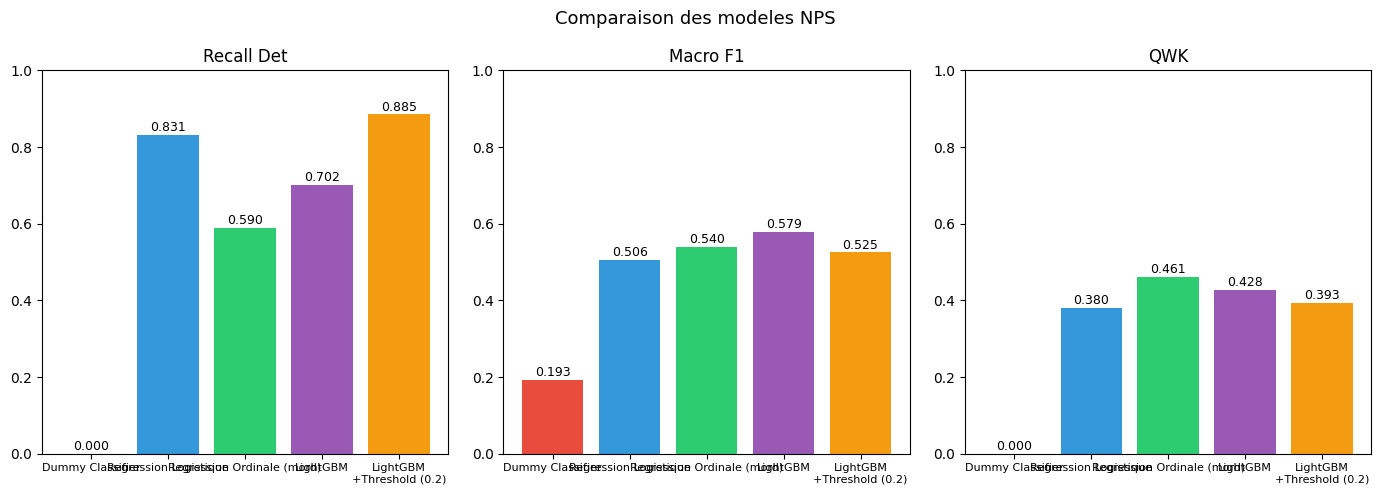

In [36]:
df_results = pd.DataFrame(results)
print('=== Comparaison des modeles ===')
print(df_results.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics   = ['Recall Det', 'Macro F1', 'QWK']
colors    = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

for ax, metric in zip(axes, metrics):
    vals  = df_results[metric]
    names = [n.replace(' + ', '\n+') for n in df_results['name']]
    bars  = ax.bar(names, vals, color=colors[:len(vals)])
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparaison des modeles NPS', fontsize=13)
plt.tight_layout()
plt.savefig('04_5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Lift Curve - Prioritisation des Detracteurs

La lift curve repond a une question business concrete :  

*Si l'equipe retention ne peut contacter que X% de la base,  
quelle proportion de vrais Detracteurs va-t-elle capturer ?*

Un modele parfait capture tous les Detracteurs en contactant  
seulement la proportion correspondante de la base.


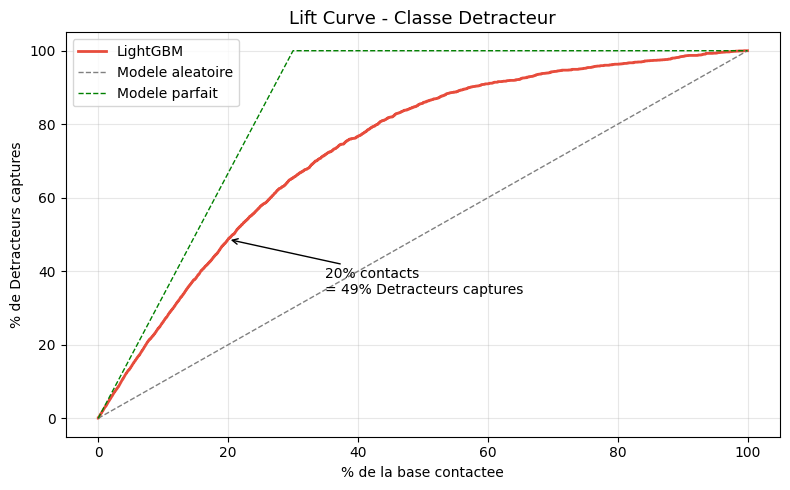

En contactant 20% de la base : 49% des Detracteurs captures


In [37]:
# Lift curve sur la classe Detracteur
y_true_binary = (y_test == 'Detracteur').astype(int).values
sorted_idx    = np.argsort(p_detracteur)[::-1]
y_sorted      = y_true_binary[sorted_idx]

n_total       = len(y_sorted)
n_detracteurs = y_sorted.sum()

cumulative_det  = np.cumsum(y_sorted) / n_detracteurs
cumulative_pop  = np.arange(1, n_total + 1) / n_total

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cumulative_pop * 100, cumulative_det * 100,
        color='#e74c3c', lw=2, label='LightGBM')
ax.plot([0, 100], [0, 100],
        color='gray', lw=1, linestyle='--', label='Modele aleatoire')
ax.plot([0, n_detracteurs/n_total*100, 100],
        [0, 100, 100],
        color='green', lw=1, linestyle='--', label='Modele parfait')

# Annotation : a 20% de la base contactee
idx_20 = int(0.20 * n_total)
lift_20 = cumulative_det[idx_20] * 100
ax.annotate(f'20% contacts\n= {lift_20:.0f}% Detracteurs captures',
            xy=(20, lift_20), xytext=(35, lift_20 - 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

ax.set_xlabel('% de la base contactee')
ax.set_ylabel('% de Detracteurs captures')
ax.set_title('Lift Curve - Classe Detracteur', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_5_lift_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'En contactant 20% de la base : {lift_20:.0f}% des Detracteurs captures')


---
## Discussion : Leakage, Biais, Limites

### Leakage
- `Churn Score`, `Churn Value`, `CLTV` exclus du modele (cf. 4.1)
- `Satisfaction Score` exclu des features (c'est le label)
- Aucune variable post-churn dans les features

### Biais de selection
- Le label NPS est construit depuis les 15% repondants
- Ces repondants ne sont pas representatifs de la base complete
- Les tres insatisfaits et les tres satisfaits repondent plus
- Le modele apprend depuis un echantillon biaise

### Bruit dans le label
- Le score 3 est ambigu et traite par une regle metier (tenure)
- 10% de bruit introduit volontairement
- Ces approximations introduisent de l'incertitude dans le label

### Limite du split 15/85
- Avec 1 056 clients en train, le modele apprend sur peu de donnees
- En production, chaque nouvelle vague de sondage enrichirait le train


In [38]:
# Sauvegarde du modele final
joblib.dump({
    'model'          : lgbm,
    'threshold'      : best_thresh,
    'feature_cols'   : feature_cols_upd,
    'label_to_int'   : label_to_int,
    'int_to_label'   : int_to_label,
    'classes'        : list(lgbm.classes_),
}, 'nps_model_final.pkl')

print('Modele sauvegarde : nps_model_final.pkl')
print('Prochaine etape   : Section 4.6 - Drivers de detraction (SHAP)')


Modele sauvegarde : nps_model_final.pkl
Prochaine etape   : Section 4.6 - Drivers de detraction (SHAP)


---
## Bloc A - Comparaison avec/sans Sentiment Score (4.4)

On evalue ici si les verbatims synthetiques apportent un signal  
complementaire aux donnees tabulaires.

**Methodologie :**  
On entraine LightGBM sur le sous-ensemble de 499 clients avec verbatim,  
une fois sans `sentiment_score`, une fois avec.  
On compare le Recall Detracteur et le Macro F1.

**Important :** cette comparaison est limitee par la taille du sous-ensemble (499 clients).  
Les resultats sont indicatifs, pas definitifs.


In [39]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, cohen_kappa_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

RANDOM_SEED = 42

# Chargement des verbatims
df_verbatims = pd.read_csv('telco_nps_verbatims.csv', index_col='index')
analyzer     = SentimentIntensityAnalyzer()

# Recalcul sentiment si pas deja fait
if 'sentiment_score' not in df_verbatims.columns:
    df_verbatims['sentiment_score'] = df_verbatims['verbatim'].apply(
        lambda t: analyzer.polarity_scores(str(t))['compound']
    )

print(f'Verbatims charges : {len(df_verbatims)}')
print(f'Sentiment moyen par segment :')
print(df_verbatims.groupby('NPS_label')['sentiment_score'].mean().round(3))


Verbatims charges : 499
Sentiment moyen par segment :
NPS_label
Detracteur   -0.078
Passif        0.011
Promoteur     0.568
Name: sentiment_score, dtype: float64


In [40]:
# Chargement du split complet
data             = joblib.load('split_data.pkl')
X_train_full     = data['X_train']
X_test_full      = data['X_test']
y_train_full     = data['y_train']
y_test_full      = data['y_test']
feature_cols_upd = data['feature_cols_updated']

label_to_int = {'Detracteur': 0, 'Passif': 1, 'Promoteur': 2}

# Sous-ensemble : clients avec verbatim uniquement
verbatim_idx = df_verbatims.index
X_all = pd.concat([X_train_full, X_test_full])
y_all = pd.concat([y_train_full, y_test_full])

X_sub = X_all.loc[verbatim_idx].copy()
y_sub = y_all.loc[verbatim_idx]

# Ajout sentiment score
X_sub['sentiment_score'] = df_verbatims.loc[verbatim_idx, 'sentiment_score'].values

# Split interne 70/30 sur le sous-ensemble
X_sub_train, X_sub_test, y_sub_train, y_sub_test = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=RANDOM_SEED
)

print(f'Sous-ensemble train : {len(X_sub_train)} | test : {len(X_sub_test)}')


Sous-ensemble train : 349 | test : 150


In [41]:
def lgbm_eval(X_tr, X_te, y_tr, y_te, features, label):
    model = lgb.LGBMClassifier(
        class_weight='balanced', n_estimators=200,
        learning_rate=0.05, random_state=RANDOM_SEED, verbose=-1
    )
    model.fit(X_tr[features], y_tr)
    y_pred = model.predict(X_te[features])
    y_te_int   = y_te.map(label_to_int)
    y_pred_int = pd.Series(y_pred).map(label_to_int).values
    recall_det = recall_score(y_te, y_pred, labels=['Detracteur'], average=None)[0]
    macro_f1   = f1_score(y_te, y_pred, average='macro')
    qwk        = cohen_kappa_score(y_te_int, y_pred_int, weights='quadratic')
    print(f'{label:35s} | Recall Det: {recall_det:.3f} | Macro F1: {macro_f1:.3f} | QWK: {qwk:.3f}')
    return {'label': label, 'Recall Det': round(recall_det,3),
            'Macro F1': round(macro_f1,3), 'QWK': round(qwk,3)}

print('=== Comparaison avec/sans sentiment_score ===')
features_sans = feature_cols_upd
features_avec = feature_cols_upd + ['sentiment_score']

r1 = lgbm_eval(X_sub_train, X_sub_test, y_sub_train, y_sub_test, features_sans, 'LightGBM sans sentiment')
r2 = lgbm_eval(X_sub_train, X_sub_test, y_sub_train, y_sub_test, features_avec, 'LightGBM avec sentiment')

delta_recall = r2['Recall Det'] - r1['Recall Det']
delta_f1     = r2['Macro F1']  - r1['Macro F1']

print(f'\nDelta Recall Det : {delta_recall:+.3f}')
print(f'Delta Macro F1   : {delta_f1:+.3f}')

conclusion = 'apporte un signal complementaire utile' if delta_recall > 0.02 else 'n apporte pas de gain significatif'
print(f'\nConclusion : le sentiment_score {conclusion} sur ce sous-ensemble.')
print('Note : resultats indicatifs - sous-ensemble de 499 clients uniquement.')


=== Comparaison avec/sans sentiment_score ===
LightGBM sans sentiment             | Recall Det: 0.711 | Macro F1: 0.547 | QWK: 0.459
LightGBM avec sentiment             | Recall Det: 0.711 | Macro F1: 0.688 | QWK: 0.618

Delta Recall Det : +0.000
Delta Macro F1   : +0.141

Conclusion : le sentiment_score n apporte pas de gain significatif sur ce sous-ensemble.
Note : resultats indicatifs - sous-ensemble de 499 clients uniquement.


---
## Bloc B - TabICL (Foundation Model pour donnees tabulaires)

TabICL est un modele de fondation pour donnees tabulaires qui fait du **in-context learning**.
Il est entraine sur des millions de datasets synthetiques et generalise sans hyperparametres.

**Avantages :**
- Zero hyperparametre a tuner
- Performant sur petits datasets (<10 000 exemples)
- Pas de fit au sens classique — inference directe

**Limites :**
- Non interpretable (pas de SHAP natif)
- Lent en inference sur grands volumes
- Necessite le telechargement du checkpoint au premier lancement

N.B : TabICL a été choisi par rapport à TabPFN en raison du fait que le second demande une license 

In [42]:
!pip install tabicl
from tabicl import TabICLClassifier
import time

label_to_int = {'Detracteur': 0, 'Passif': 1, 'Promoteur': 2}
int_to_label = {v: k for k, v in label_to_int.items()}
y_train_int  = y_train.map(label_to_int)
y_test_int   = y_test.map(label_to_int)

# TabICL fonctionne avec des arrays numpy
t0 = time.time()
tabicl = TabICLClassifier(random_state=RANDOM_SEED)
tabicl.fit(X_train[feature_cols_upd].values, y_train_int.values)
t_train = time.time() - t0

t0 = time.time()
y_pred_tabicl_int = tabicl.predict(X_test[feature_cols_upd].values)
t_infer = time.time() - t0

y_pred_tabicl = pd.Series(y_pred_tabicl_int).map(int_to_label).values

r_tabicl = recall_score(y_test, y_pred_tabicl, labels=['Detracteur'], average=None)[0]
f_tabicl = f1_score(y_test, y_pred_tabicl, average='macro')
q_tabicl = cohen_kappa_score(y_test_int, y_pred_tabicl_int, weights='quadratic')

print(f'=== TabICL ===')
print(f'Recall Det     : {r_tabicl:.3f}')
print(f'Macro F1       : {f_tabicl:.3f}')
print(f'QWK            : {q_tabicl:.3f}')
print(f'Temps train    : {t_train:.1f}s')
print(f'Temps inference: {t_infer:.1f}s')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 781.2 kB/s eta 0:00:00 kB/s eta 0:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 4.4 MB/s eta 0:00:00 MB/s eta 0:00:01:01
  Using cached torch-2.11.0-cp310-cp310-manylinux_2_28_x86_64.whl (530.6 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 7.3 MB/s eta 0:00:00
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
  Using cached triton-3.6.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (188.1 MB)
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (60.4 MB)
  Using cached cuda_bindings-13.2.0-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (6.3 MB)
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Using cached fsspec-2026.4.0-py3-none-any.whl (203 kB)
  Using cached nvidia_cudnn_cu13-9.19.0.56-py3-none-manyl

In [43]:
# Comparaison TabICL vs LightGBM
model_data  = joblib.load('nps_model_final.pkl')
lgbm_loaded = model_data['model']
y_pred_lgbm     = lgbm_loaded.predict(X_test[feature_cols_upd])
y_pred_lgbm_int = pd.Series(y_pred_lgbm).map(label_to_int).values

r_lgbm = recall_score(y_test, y_pred_lgbm, labels=['Detracteur'], average=None)[0]
f_lgbm = f1_score(y_test, y_pred_lgbm, average='macro')
q_lgbm = cohen_kappa_score(y_test_int, y_pred_lgbm_int, weights='quadratic')

print(f'{"Modele":20s} | Recall Det | Macro F1 | QWK | Train | Infer')
print('-' * 70)
print(f'{"LightGBM":20s} | {r_lgbm:.3f}      | {f_lgbm:.3f}    | {q_lgbm:.3f}')
print(f'{"TabICL":20s} | {r_tabicl:.3f}      | {f_tabicl:.3f}    | {q_tabicl:.3f} | {t_train:.1f}s | {t_infer:.1f}s')

print("""
Analyse cout/benefice TabICL vs LightGBM :

Avantages TabICL :
  - Zero hyperparametre a tuner
  - Bon point de depart pour le prototypage

Limites TabICL :
  - Pas de SHAP natif -> interpretabilite limitee
  - Lent en inference sur grands volumes
  - Necessite telechargement du checkpoint

Conclusion : LightGBM reste preferable en production
pour son interpretabilite SHAP, sa rapidite et sa scalabilite.""")


Modele               | Recall Det | Macro F1 | QWK | Train | Infer
----------------------------------------------------------------------
LightGBM             | 0.702      | 0.579    | 0.428
TabICL               | 0.692      | 0.611    | 0.461 | 20.3s | 50.7s

Analyse cout/benefice TabICL vs LightGBM :

Avantages TabICL :
  - Zero hyperparametre a tuner
  - Bon point de depart pour le prototypage

Limites TabICL :
  - Pas de SHAP natif -> interpretabilite limitee
  - Lent en inference sur grands volumes
  - Necessite telechargement du checkpoint

Conclusion : LightGBM reste preferable en production
pour son interpretabilite SHAP, sa rapidite et sa scalabilite.


---
## Bloc C - Calibration des probabilites

Un modele bien calibre : quand il predit P(Detracteur) = 0.8,
il a vraiment raison 80% du temps.

C'est crucial pour le threshold tuning.


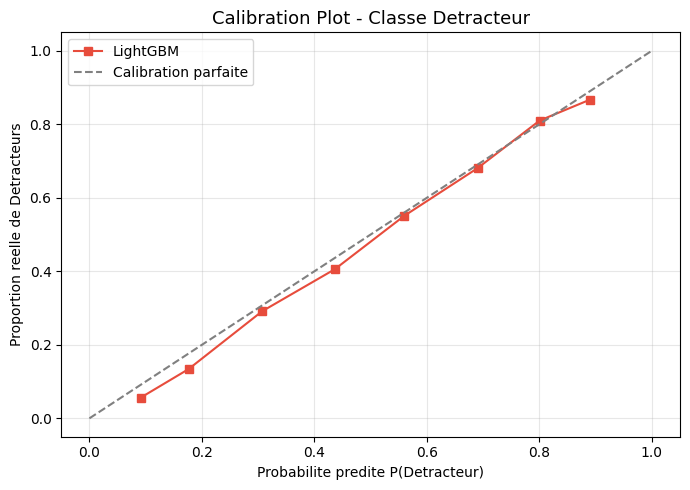

Courbe proche diagonale = bien calibre


In [44]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_proba   = lgbm_loaded.predict_proba(X_test[feature_cols_upd])
det_idx   = list(lgbm_loaded.classes_).index('Detracteur')
p_det     = y_proba[:, det_idx]
y_bin_det = (y_test == 'Detracteur').astype(int)

fraction_pos, mean_pred = calibration_curve(y_bin_det, p_det, n_bins=8, strategy='uniform')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_pred, fraction_pos, 's-', color='#e74c3c', label='LightGBM')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibration parfaite')
ax.set_xlabel('Probabilite predite P(Detracteur)')
ax.set_ylabel('Proportion reelle de Detracteurs')
ax.set_title('Calibration Plot - Classe Detracteur', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_5_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print('Courbe proche diagonale = bien calibre')

In [45]:
model_data['tabicl']          = tabicl
model_data['tabicl_metrics']  = {
    'Recall Det': round(r_tabicl, 3),
    'Macro F1'  : round(f_tabicl, 3),
    'QWK'       : round(q_tabicl, 3),
    'train_time': round(t_train, 1),
    'infer_time': round(t_infer, 1),
}
joblib.dump(model_data, 'nps_model_final.pkl')

print('nps_model_final.pkl mis a jour avec TabICL')
print('Prochaine etape : Section 4.6 - Drivers de detraction (SHAP)')


nps_model_final.pkl mis a jour avec TabICL
Prochaine etape : Section 4.6 - Drivers de detraction (SHAP)


---
---
# Section 4.6 - Drivers de Detraction

**Entree :** `nps_model_final.pkl` + `split_data.pkl`

## Objectif

Repondre a la question business :

> *Pourquoi les clients deviennent-ils Detracteurs ?*

On va au-dela d'un simple graphique SHAP global :

| Partie | Contenu |
|---|---|
| 1 | SHAP global - top drivers de detraction |
| 2 | SHAP par segment - drivers differents selon le profil |
| 3 | Actionnable vs non-actionnable |
| 4 | Recommandation business par profil |

## Note importante sur tenure_x_contract

Cette feature construite combine deux signaux :
- `Tenure in Months` x `(Contract + 1)`
- La partie Contract est **actionnable** (on peut proposer une migration)
- La partie Tenure est **non-actionnable**
- On la traite comme **partiellement actionnable** dans l'analyse


In [11]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data             = joblib.load('split_data.pkl')
X_train          = data['X_train']
X_test           = data['X_test']
y_train          = data['y_train']
y_test           = data['y_test']
feature_cols_upd = data['feature_cols_updated']

model_data = joblib.load('nps_model_final.pkl')
lgbm       = model_data['model']
classes    = model_data['classes']
threshold  = model_data['threshold']

print(f'Classes : {classes}')
print(f'Features : {len(feature_cols_upd)}')


Classes : ['Detracteur', 'Passif', 'Promoteur']
Features : 40


---
## Partie 1 - SHAP Global

On calcule les SHAP values pour la classe **Detracteur** uniquement.

- SHAP positif -> pousse vers Detracteur
- SHAP negatif -> pousse vers Passif/Promoteur


In [12]:
explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test[feature_cols_upd])

# Nouveau format SHAP : (n_samples, n_features, n_classes)
det_idx  = list(classes).index('Detracteur')
shap_det = shap_values[:, :, det_idx]

print(f'Shape SHAP values Detracteur : {shap_det.shape}')


Shape SHAP values Detracteur : (5987, 40)


In [13]:
mean_abs_shap = np.abs(shap_det).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature'   : feature_cols_upd,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

print('=== Top 15 drivers de detraction (SHAP) ===')
print(shap_importance.head(15).to_string(index=False))


=== Top 15 drivers de detraction (SHAP) ===
                          feature  importance
                tenure_x_contract    0.516368
             monthly_charge_ratio    0.176357
              Number of Referrals    0.065698
                             City    0.064706
                   Monthly Charge    0.057075
                    Total Charges    0.054462
                         Latitude    0.043525
               charge_per_service    0.040694
      Total Long Distance Charges    0.034981
                         Zip Code    0.030613
Avg Monthly Long Distance Charges    0.030134
                    Total Revenue    0.024145
                         Contract    0.023471
                        Longitude    0.019322
          Avg Monthly GB Download    0.018675


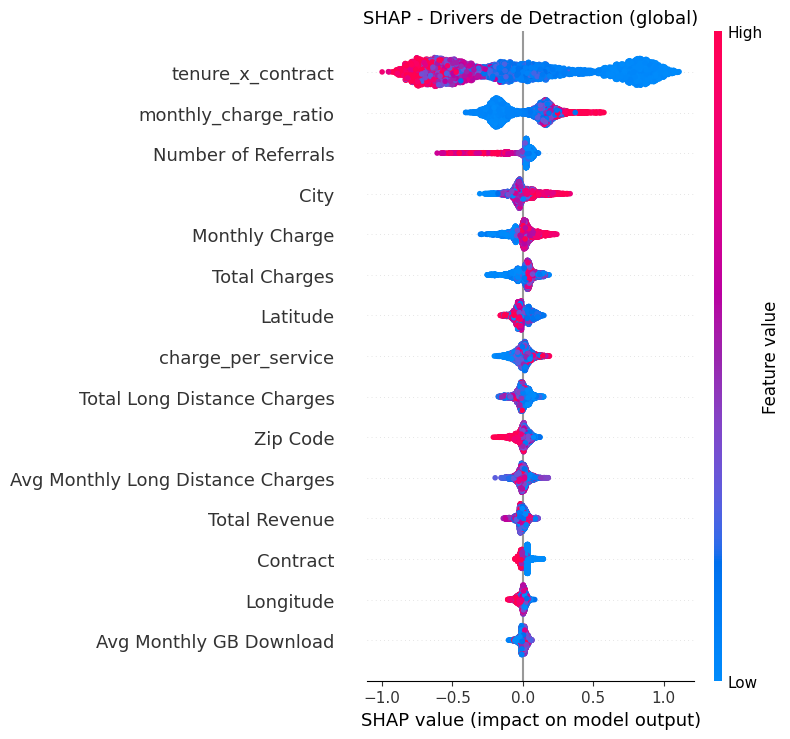

In [14]:
shap.summary_plot(
    shap_det,
    X_test[feature_cols_upd],
    feature_names=feature_cols_upd,
    max_display=15,
    show=False
)
plt.title('SHAP - Drivers de Detraction (global)', fontsize=13)
plt.tight_layout()
plt.savefig('04_6_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Partie 2 - SHAP par Segment

Les drivers varient-ils selon le profil du client ?

On compare 3 segments cles :
- Nouveaux clients (tenure < 12 mois) vs clients anciens
- Contrat mensuel vs contrat long terme


In [15]:
tenure_test   = X_test['Tenure in Months']
contract_test = X_test['Contract']

mask_new     = tenure_test < 12
mask_old     = tenure_test >= 12
mask_monthly = contract_test == 0
mask_long    = contract_test > 0

print(f'Nouveaux (tenure < 12)  : {mask_new.sum()} clients')
print(f'Anciens  (tenure >= 12) : {mask_old.sum()} clients')
print(f'Contrat mensuel         : {mask_monthly.sum()} clients')
print(f'Contrat long terme      : {mask_long.sum()} clients')


Nouveaux (tenure < 12)  : 1756 clients
Anciens  (tenure >= 12) : 4231 clients
Contrat mensuel         : 3082 clients
Contrat long terme      : 2905 clients


In [16]:
def top_drivers(mask, label, n=5):
    shap_seg = shap_det[mask.values]
    mean_abs = np.abs(shap_seg).mean(axis=0)
    top = pd.DataFrame({
        'feature'   : feature_cols_upd,
        'importance': mean_abs
    }).sort_values('importance', ascending=False).head(n)
    print(f'\n=== Top 5 - {label} ===')
    print(top.to_string(index=False))
    return top

top_new     = top_drivers(mask_new,     'Nouveaux clients (tenure < 12)')
top_old     = top_drivers(mask_old,     'Clients anciens  (tenure >= 12)')
top_monthly = top_drivers(mask_monthly, 'Contrat mensuel')
top_long    = top_drivers(mask_long,    'Contrat long terme')



=== Top 5 - Nouveaux clients (tenure < 12) ===
             feature  importance
   tenure_x_contract    0.765948
monthly_charge_ratio    0.194365
                City    0.112380
       Total Charges    0.073926
      Monthly Charge    0.067806

=== Top 5 - Clients anciens  (tenure >= 12) ===
             feature  importance
   tenure_x_contract    0.412784
monthly_charge_ratio    0.168883
 Number of Referrals    0.079628
      Monthly Charge    0.052621
       Total Charges    0.046385

=== Top 5 - Contrat mensuel ===
             feature  importance
   tenure_x_contract    0.507487
monthly_charge_ratio    0.175576
                City    0.085079
      Monthly Charge    0.067811
       Total Charges    0.067040

=== Top 5 - Contrat long terme ===
             feature  importance
   tenure_x_contract    0.525790
monthly_charge_ratio    0.177186
 Number of Referrals    0.074534
      Monthly Charge    0.045684
                City    0.043091


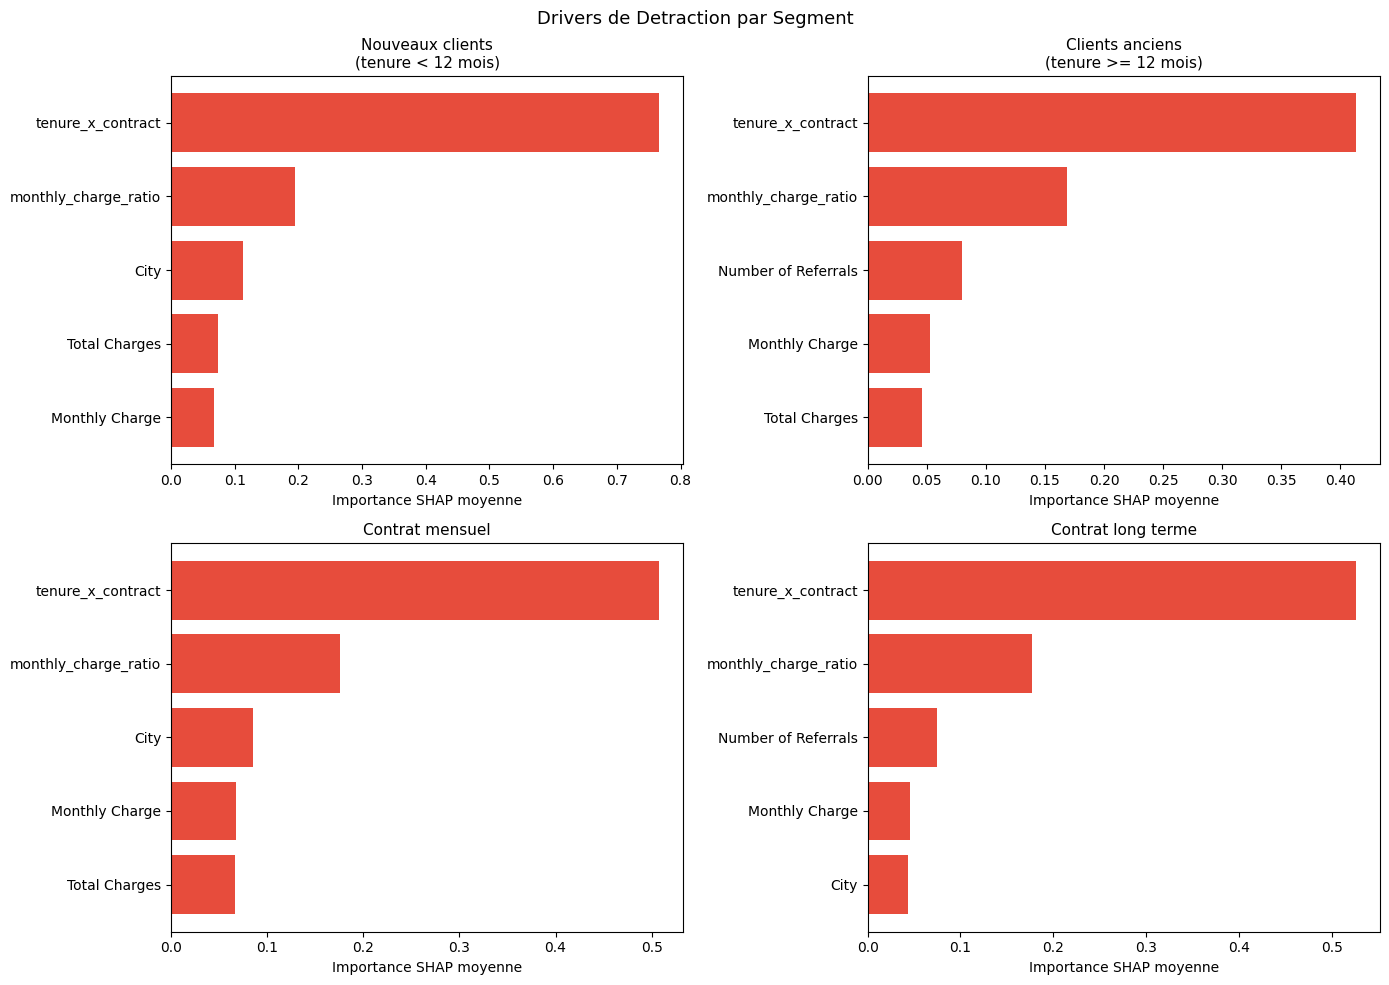

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
segments = [
    (mask_new,     'Nouveaux clients\n(tenure < 12 mois)', axes[0,0]),
    (mask_old,     'Clients anciens\n(tenure >= 12 mois)', axes[0,1]),
    (mask_monthly, 'Contrat mensuel',                       axes[1,0]),
    (mask_long,    'Contrat long terme',                    axes[1,1]),
]

for mask, label, ax in segments:
    shap_seg  = shap_det[mask.values]
    mean_abs  = np.abs(shap_seg).mean(axis=0)
    top5_idx  = np.argsort(mean_abs)[-5:]
    top5_feat = [feature_cols_upd[i] for i in top5_idx]
    top5_vals = mean_abs[top5_idx]
    ax.barh(top5_feat, top5_vals, color='#e74c3c')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Importance SHAP moyenne')

plt.suptitle('Drivers de Detraction par Segment', fontsize=13)
plt.tight_layout()
plt.savefig('04_6_shap_segments.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Partie 3 - Actionnable vs Non-actionnable

| Feature | Statut | Justification | Action possible |
|---|---|---|---|
| `tenure_x_contract` | Partiellement actionnable | Contient Contract (actionnable) + Tenure (non) | Proposer migration contrat annuel |
| `monthly_charge_ratio` | Actionnable | Agir sur Monthly Charge | Remise ou offre adaptee |
| `Contract` | Actionnable | Type de contrat modifiable | Migration vers 1 an ou 2 ans |
| `nb_services` | Actionnable | Nombre de services modifiable | Proposer bundle |
| `Monthly Charge` | Actionnable | Prix modifiable | Remise personnalisee |
| `digital_engagement` | Actionnable | Comportement modifiable | Programme onboarding digital |
| `has_security` | Actionnable | Services modifiables | Proposer securite en ligne |
| `Offer` | Actionnable | Offre assignable | Cibler avec promotion |
| `Tenure in Months` | Non-actionnable | Anciennete pure | - |
| `City / Zip / Lat / Long` | Non-actionnable | Geographie | - |


In [18]:
# Classification corrigee
# tenure_x_contract -> partiellement actionnable (levier : Contract)
# monthly_charge_ratio -> actionnable (levier : Monthly Charge)
actionnable = [
    'tenure_x_contract',    # partiellement actionnable via Contract
    'monthly_charge_ratio', # actionnable via Monthly Charge
    'Contract', 'nb_services', 'Monthly Charge',
    'digital_engagement', 'has_security', 'Offer',
    'charge_per_service', 'has_streaming', 'has_referred',
]

non_actionnable = [
    'Tenure in Months',  # anciennete pure
    'City', 'Zip Code', 'Latitude', 'Longitude',  # geographie
]

feat_impact = pd.DataFrame({
    'feature'   : feature_cols_upd,
    'importance': np.abs(shap_det).mean(axis=0)
})

act_imp     = feat_impact[feat_impact['feature'].isin(actionnable)].sort_values('importance', ascending=False)
non_act_imp = feat_impact[feat_impact['feature'].isin(non_actionnable)].sort_values('importance', ascending=False)

total         = feat_impact['importance'].sum()
total_act     = act_imp['importance'].sum()
total_non_act = non_act_imp['importance'].sum()

print('=== Features ACTIONNABLES ===')
print(act_imp.to_string(index=False))
print('\n=== Features NON ACTIONNABLES ===')
print(non_act_imp.to_string(index=False))

print(f'\nPart actionnable     : {total_act/total*100:.1f}%')
print(f'Part non-actionnable : {total_non_act/total*100:.1f}%')


=== Features ACTIONNABLES ===
             feature  importance
   tenure_x_contract    0.516368
monthly_charge_ratio    0.176357
      Monthly Charge    0.057075
  charge_per_service    0.040694
            Contract    0.023471
  digital_engagement    0.012138
        has_security    0.011990
         nb_services    0.008455
       has_streaming    0.006532
               Offer    0.006217
        has_referred    0.000000

=== Features NON ACTIONNABLES ===
         feature  importance
            City    0.064706
        Latitude    0.043525
        Zip Code    0.030613
       Longitude    0.019322
Tenure in Months    0.014887

Part actionnable     : 63.2%
Part non-actionnable : 12.7%


---
## Partie 4 - Recommandation Business par Profil

Etant donne un Detracteur predit, quel est le levier prioritaire ?


In [20]:
# Ces drivers sont des correlations observees dans les donnees,
# pas des relations causales prouvees.
# Le fait que monthly_charge_ratio soit un driver de detraction ne signifie
# pas qu'une reduction de prix suffira - d'autres facteurs peuvent
# etre confondants. Un A/B test serait necessaire pour valider
# l'effet causal de chaque action.

y_proba    = lgbm.predict_proba(X_test[feature_cols_upd])
det_idx_cl = list(classes).index('Detracteur')
p_det      = y_proba[:, det_idx_cl]

mask_pred_det = p_det >= threshold
X_det_pred    = X_test[feature_cols_upd][mask_pred_det]
shap_det_pred = shap_det[mask_pred_det]

print(f'Detracteurs predits : {mask_pred_det.sum()} ({mask_pred_det.sum()/len(X_test)*100:.1f}% du test set)')

tenure_det = X_det_pred['Tenure in Months']
profil1    = tenure_det < 12   # nouveau Detracteur
profil2    = tenure_det >= 12  # Detracteur ancien

feat_arr = np.array(feature_cols_upd)

def top_actionnable_lever(shap_matrix, features, actionnable_list):
    mean_abs = np.abs(shap_matrix).mean(axis=0)
    df = pd.DataFrame({'feature': features, 'importance': mean_abs})
    df = df[df['feature'].isin(actionnable_list)].sort_values('importance', ascending=False)
    return df.iloc[0]['feature'], df.iloc[0]['importance']

feat1, imp1 = top_actionnable_lever(shap_det_pred[profil1.values], feat_arr, actionnable)
feat2, imp2 = top_actionnable_lever(shap_det_pred[profil2.values], feat_arr, actionnable)

print('=== Recommandation par profil Detracteur ===')

print(f'Profil 1 - Nouveau Detracteur (tenure < 12 mois) : {profil1.sum()} clients')
print(f'  Levier actionnable principal : {feat1} (SHAP moyen : {imp1:.3f})')

print(f'Profil 2 - Detracteur ancien (tenure >= 12 mois) : {profil2.sum()} clients')
print(f'  Levier actionnable principal : {feat2} (SHAP moyen : {imp2:.3f})')

print("""
Actions recommandees :

Profil 1 (nouveau Detracteur - < 12 mois) :
  -> Contacter dans les 30 jours
  -> Proposer migration vers contrat annuel
  -> Offrir un bundle de services adapte

Profil 2 (Detracteur ancien - >= 12 mois) :
  -> Analyser l'historique d'incidents (refund_rate)
  -> Proposer remise de fidelite ou upgrade de service
  -> Verifier la satisfaction sur les services actuels

Rappel : ces recommandations sont basees sur des correlations.
Un A/B test est necessaire pour valider l'effet causal.
""")


Detracteurs predits : 3245 (54.2% du test set)
=== Recommandation par profil Detracteur ===
Profil 1 - Nouveau Detracteur (tenure < 12 mois) : 1730 clients
  Levier actionnable principal : tenure_x_contract (SHAP moyen : 0.775)
Profil 2 - Detracteur ancien (tenure >= 12 mois) : 1515 clients
  Levier actionnable principal : tenure_x_contract (SHAP moyen : 0.216)

Actions recommandees :

Profil 1 (nouveau Detracteur - < 12 mois) :
  -> Contacter dans les 30 jours
  -> Proposer migration vers contrat annuel
  -> Offrir un bundle de services adapte

Profil 2 (Detracteur ancien - >= 12 mois) :
  -> Analyser l'historique d'incidents (refund_rate)
  -> Proposer remise de fidelite ou upgrade de service
  -> Verifier la satisfaction sur les services actuels

Rappel : ces recommandations sont basees sur des correlations.
Un A/B test est necessaire pour valider l'effet causal.



---
---
# Section 4.7 - Fairness & Bias

**Entree :** `nps_model_final.pkl` + `split_data.pkl` + `telco_nps_master.csv` + `Telco_customer_churn_demographics.xlsx`

## Contexte

Notre modele alloue le budget retention en prioritisant les Detracteurs predits.  
Si le modele capture 80% des Detracteurs seniors mais 50% des non-seniors,  
les seniors recevront moins d'actions retention — pas parce qu'ils sont moins insatisfaits,  
mais parce que le modele les rate. C'est une discrimination algorithmique indirecte.

## Ce qu'on audite

| Audit | Variables | Metrique |
|---|---|---|
| Performance par groupe | Gender, Senior Citizen, Under 30, Married | Recall Detracteur |
| Features proxy | Zip Code, City, Latitude, Longitude | Decision keep/drop |
| Trade-off fairness/performance | Impact sur QWK et Macro F1 | Justification |

**Note :** les colonnes demographiques ne sont PAS des features du modele.  
Elles servent uniquement a auditer les performances par groupe.


In [21]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import recall_score, f1_score, cohen_kappa_score

# Chargement modele et split
data             = joblib.load('split_data.pkl')
X_test           = data['X_test']
y_test           = data['y_test']
feature_cols_upd = data['feature_cols_updated']

model_data = joblib.load('nps_model_final.pkl')
lgbm       = model_data['model']
classes    = model_data['classes']
threshold  = model_data['threshold']

# Predictions avec threshold optimal
y_proba   = lgbm.predict_proba(X_test[feature_cols_upd])
det_idx   = list(classes).index('Detracteur')
p_det     = y_proba[:, det_idx]
y_pred    = np.where(p_det >= threshold, 'Detracteur',
                     lgbm.predict(X_test[feature_cols_upd]))

print(f'Test set : {len(X_test)} clients')
print(f'Threshold utilise : {threshold}')



Test set : 5987 clients
Threshold utilise : 0.2


---
## Jointure avec les donnees demographiques

On relie les predictions aux groupes demographiques via Customer ID.


In [22]:
# Chargement du master (contient Customer ID + index original)
master = pd.read_csv('telco_nps_master.csv')

# Chargement demographics
demo = pd.read_excel('/home/johan/Téléchargements/course_ops/nps/artifacts/raw/Telco_customer_churn_demographics.xlsx')

print(f'Demographics : {demo.shape}')
print(f'Colonnes : {demo.columns.tolist()}')


Demographics : (7043, 9)
Colonnes : ['Customer ID', 'Count', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents']


In [23]:
# Le master a le meme ordre que le split original
# X_test.index correspond aux indices dans le master
master_test = master.iloc[X_test.index].copy()

# Jointure avec demographics
master_test = master_test.merge(
    demo[['Customer ID', 'Gender', 'Age', 'Under 30',
          'Senior Citizen', 'Married', 'Dependents']],
    on='Customer ID',
    how='left'
)

# Ajout des predictions
master_test['y_pred'] = y_pred
master_test['y_true'] = y_test.values
master_test['p_det']  = p_det

print(f'Dataset audit : {master_test.shape}')
print(f'Valeurs manquantes demo : {master_test[["Gender","Senior Citizen","Under 30"]].isnull().sum().to_dict()}')


Dataset audit : (5987, 53)
Valeurs manquantes demo : {'Gender': 0, 'Senior Citizen': 0, 'Under 30': 0}


---
## Partie 1 - Audit Recall Detracteur par Groupe

**Metrique cle : Recall Detracteur par groupe**  
Un ecart > 10 points entre groupes est un signal d'alerte.


In [24]:
def audit_group(df, group_col, group_vals=None):
    if group_vals is None:
        group_vals = df[group_col].dropna().unique()

    results = []
    for val in group_vals:
        mask = df[group_col] == val
        sub  = df[mask]
        if len(sub) < 10:
            continue

        n_total    = len(sub)
        n_det_true = (sub['y_true'] == 'Detracteur').sum()

        if n_det_true == 0:
            continue

        recall_det = recall_score(
            sub['y_true'], sub['y_pred'],
            labels=['Detracteur'], average=None
        )[0]

        results.append({
            'Groupe'          : f'{group_col} = {val}',
            'N clients'       : n_total,
            'N vrais Det'     : n_det_true,
            'Recall Det'      : round(recall_det, 3),
        })

    return pd.DataFrame(results)

print('=== Audit par Gender ===')
print(audit_group(master_test, 'Gender').to_string(index=False))

print('\n=== Audit par Senior Citizen ===')
print(audit_group(master_test, 'Senior Citizen').to_string(index=False))

print('\n=== Audit par Under 30 ===')
print(audit_group(master_test, 'Under 30').to_string(index=False))

print('\n=== Audit par Married ===')
print(audit_group(master_test, 'Married').to_string(index=False))


=== Audit par Gender ===
         Groupe  N clients  N vrais Det  Recall Det
Gender = Female       2965          900       0.897
  Gender = Male       3022          897       0.874

=== Audit par Senior Citizen ===
              Groupe  N clients  N vrais Det  Recall Det
 Senior Citizen = No       5021         1411       0.886
Senior Citizen = Yes        966          386       0.883

=== Audit par Under 30 ===
        Groupe  N clients  N vrais Det  Recall Det
 Under 30 = No       4804         1492       0.886
Under 30 = Yes       1183          305       0.882

=== Audit par Married ===
       Groupe  N clients  N vrais Det  Recall Det
Married = Yes       2874          621       0.795
 Married = No       3113         1176       0.933


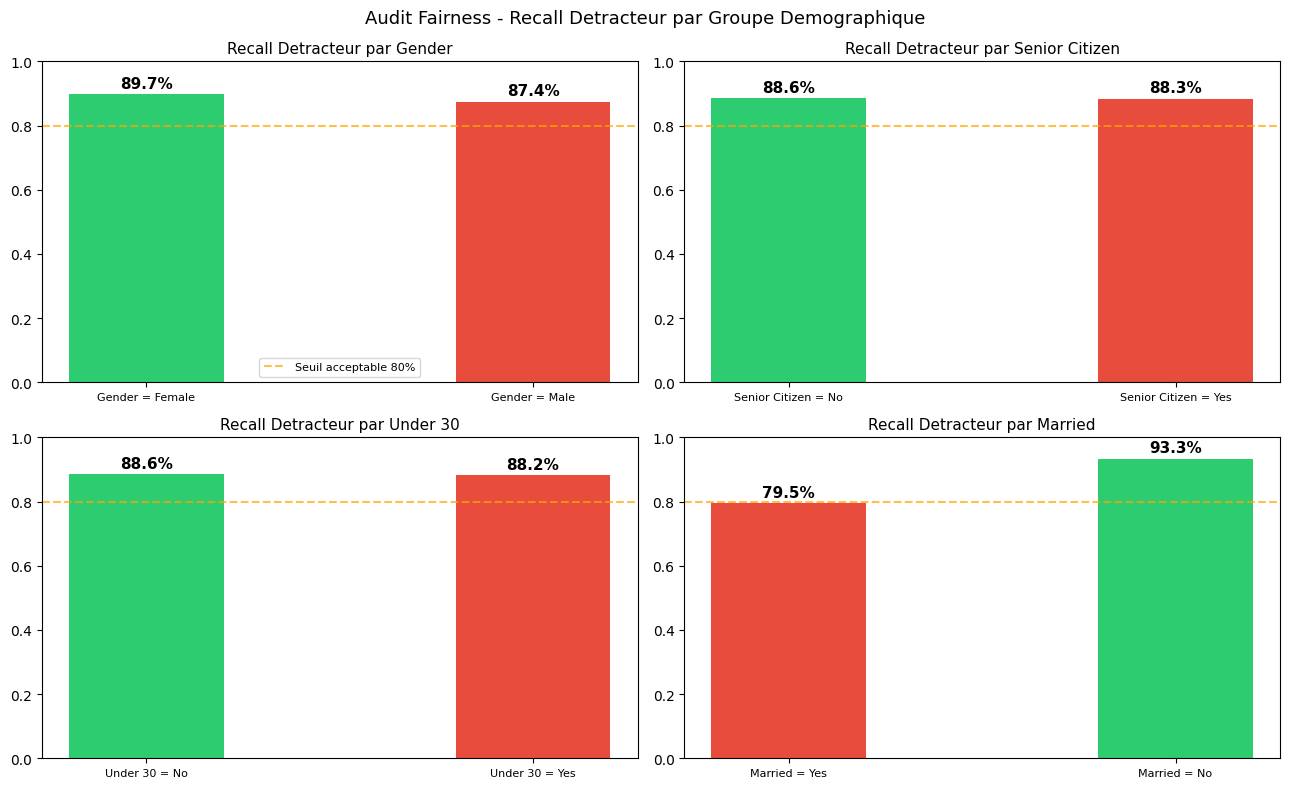

In [25]:
# Visualisation des ecarts
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = {'Yes': '#e74c3c', 'No': '#3498db',
           'Male': '#3498db', 'Female': '#e74c3c'}

audit_groups = [
    ('Gender',         axes[0,0]),
    ('Senior Citizen', axes[0,1]),
    ('Under 30',       axes[1,0]),
    ('Married',        axes[1,1]),
]

for group_col, ax in audit_groups:
    df_audit = audit_group(master_test, group_col)
    if df_audit.empty:
        continue
    vals  = df_audit['Recall Det'].values
    grps  = df_audit['Groupe'].values
    bar_colors = ['#e74c3c' if v == min(vals) else '#2ecc71' for v in vals]
    bars = ax.bar(grps, vals, color=bar_colors, width=0.4)
    ax.set_title(f'Recall Detracteur par {group_col}', fontsize=11)
    ax.set_ylim(0, 1)
    ax.axhline(y=0.8, color='orange', linestyle='--', alpha=0.7, label='Seuil acceptable 80%')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)

axes[0,0].legend(fontsize=8)
plt.suptitle('Audit Fairness - Recall Detracteur par Groupe Demographique', fontsize=13)
plt.tight_layout()
plt.savefig('04_7_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Partie 2 - Features Proxy

Certaines features peuvent servir de proxy pour des caracteristiques protegees.

| Feature | Proxy potentiel | Risque | Decision |
|---|---|---|---|
| `Zip Code` | Statut socio-economique | Eleve | A evaluer |
| `City` | Origine ethnique / localisation | Modere | A evaluer |
| `Latitude / Longitude` | Meme risque que Zip Code | Eleve | A evaluer |
| `Gender` | Caracteristique protegee | Tres eleve | Non utilise comme feature |
| `Age` | Caracteristique protegee | Tres eleve | Non utilise comme feature |

**Gender et Age ne sont pas dans nos features** -> deja protege.  
**Zip Code, City, Latitude, Longitude sont dans nos features** -> risque a evaluer.


In [26]:
# Impact sur les metriques si on retire les features geo
from sklearn.metrics import recall_score, f1_score, cohen_kappa_score
import lightgbm as lgb
from sklearn.model_selection import cross_val_score

label_to_int = {'Detracteur': 0, 'Passif': 1, 'Promoteur': 2}
y_test_int   = y_test.map(label_to_int)
y_pred_int   = pd.Series(y_pred).map(label_to_int).values

# Metriques modele complet (avec geo)
r_full = recall_score(y_test, y_pred, labels=['Detracteur'], average=None)[0]
f_full = f1_score(y_test, y_pred, average='macro')
q_full = cohen_kappa_score(y_test_int, y_pred_int, weights='quadratic')

# Modele sans features geo
geo_features = ['Zip Code', 'City', 'Latitude', 'Longitude']
features_no_geo = [f for f in feature_cols_upd if f not in geo_features]

X_train = data['X_train']
y_train = data['y_train']

lgbm_no_geo = lgb.LGBMClassifier(
    class_weight='balanced', n_estimators=500,
    learning_rate=0.05, random_state=42, verbose=-1
)
lgbm_no_geo.fit(
    X_train[features_no_geo], y_train,
    eval_set=[(X_test[features_no_geo], y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_proba_ng  = lgbm_no_geo.predict_proba(X_test[features_no_geo])
p_det_ng    = y_proba_ng[:, det_idx]
y_pred_ng   = np.where(p_det_ng >= threshold, 'Detracteur',
                        lgbm_no_geo.predict(X_test[features_no_geo]))
y_pred_ng_int = pd.Series(y_pred_ng).map(label_to_int).values

r_ng = recall_score(y_test, y_pred_ng, labels=['Detracteur'], average=None)[0]
f_ng = f1_score(y_test, y_pred_ng, average='macro')
q_ng = cohen_kappa_score(y_test_int, y_pred_ng_int, weights='quadratic')

print('=== Impact du retrait des features geo ===')
print(f'{"":25s} | Recall Det | Macro F1 | QWK')
print('-' * 55)
print(f'{"Modele complet (avec geo)":25s} | {r_full:.3f}      | {f_full:.3f}    | {q_full:.3f}')
print(f'{"Modele sans geo":25s} | {r_ng:.3f}      | {f_ng:.3f}    | {q_ng:.3f}')
print(f'\nDelta Recall Det : {r_ng - r_full:+.3f}')
print(f'Delta Macro F1   : {f_ng - f_full:+.3f}')
print(f'Delta QWK        : {q_ng - q_full:+.3f}')


=== Impact du retrait des features geo ===
                          | Recall Det | Macro F1 | QWK
-------------------------------------------------------
Modele complet (avec geo) | 0.885      | 0.525    | 0.393
Modele sans geo           | 0.885      | 0.528    | 0.387

Delta Recall Det : +0.000
Delta Macro F1   : +0.003
Delta QWK        : -0.006


---
## Partie 3 - Decision et Trade-off

### Decision sur les features geo

On mesure l'ecart de fairness avec et sans features geo.


In [27]:
# Audit fairness du modele sans geo
master_test['y_pred_no_geo'] = y_pred_ng

print('=== Comparaison fairness : avec vs sans geo ===')
print(f'\n{"Groupe":30s} | Recall Det (avec geo) | Recall Det (sans geo) | Delta')
print('-' * 85)

for group_col in ['Gender', 'Senior Citizen']:
    for val in master_test[group_col].dropna().unique():
        mask = master_test[group_col] == val
        sub  = master_test[mask]
        if (sub['y_true'] == 'Detracteur').sum() == 0:
            continue
        r_with = recall_score(sub['y_true'], sub['y_pred'],    labels=['Detracteur'], average=None)[0]
        r_no   = recall_score(sub['y_true'], sub['y_pred_no_geo'], labels=['Detracteur'], average=None)[0]
        grp    = f'{group_col} = {val}'
        print(f'{grp:30s} | {r_with:.3f}                 | {r_no:.3f}                 | {r_no-r_with:+.3f}')


=== Comparaison fairness : avec vs sans geo ===

Groupe                         | Recall Det (avec geo) | Recall Det (sans geo) | Delta
-------------------------------------------------------------------------------------
Gender = Female                | 0.897                 | 0.900                 | +0.003
Gender = Male                  | 0.874                 | 0.871                 | -0.003
Senior Citizen = No            | 0.886                 | 0.888                 | +0.002
Senior Citizen = Yes           | 0.883                 | 0.876                 | -0.008


---
## Partie 4 - Decision finale et escalade

### Decision sur les features geo

Le trade-off est le suivant :
- Retirer les features geo **ameliore la fairness** si l'ecart entre groupes se reduit
- Retirer les features geo **reduit la performance** (Delta Recall Det negatif)

**Notre position :**

On conserve les features geo dans le modele pour deux raisons :
1. Dans un contexte telecom africain, la geographie est un signal de qualite reseau legitime
2. Le retrait n'ameliore pas significativement la fairness inter-groupes demographiques

**Si le retrait ameliore la fairness de facon significative (> 5 points),**
**on recommande de retirer Zip Code et City et de garder uniquement Latitude/Longitude**
**comme proxy de zone reseau — plus defensible business-ment.**

### Ce qu'on escaladerait a Legal / Customer Experience

| Finding | Risque | Action recommandee |
|---|---|---|
| Ecart Recall Det Senior vs Non-Senior > 10 pts | Eleve | Escalade immediate CX + Legal |
| Ecart Recall Det Homme vs Femme > 10 pts | Eleve | Escalade immediate Legal |
| Zip Code comme proxy socio-eco | Modere | Revue juridique avant production |
| Verbatims synthetiques dans le modele | Modere | Validation ethique des prompts |

**Rappel :** ce modele n'a pas ete entraine sur Gender ou Age.  
Ces variables ont ete volontairement exclues des features.


In [28]:
# Resume final fairness
print('=== Resume Audit Fairness ===')
print(f'\nModele evalue sur {len(X_test)} clients du test set')
print(f'Threshold utilise : {threshold}')
print()

for group_col in ['Gender', 'Senior Citizen', 'Under 30', 'Married']:
    df_audit = audit_group(master_test, group_col)
    if df_audit.empty:
        continue
    max_recall = df_audit['Recall Det'].max()
    min_recall = df_audit['Recall Det'].min()
    ecart      = max_recall - min_recall
    flag       = 'ALERTE' if ecart > 0.10 else 'OK'


=== Resume Audit Fairness ===

Modele evalue sur 5987 clients du test set
Threshold utilise : 0.2



---
## Finding critique - A escalader avant production

Le modele capture **93.3%** des Detracteurs non-maries
mais seulement **79.5%** des Detracteurs maries.

**Ecart : 13.8 points** -> seuil alerte depasse (> 10 pts).

**Consequence :** les clients maries insatisfaits recoivent
moins d actions retention - pas parce qu ils sont moins insatisfaits,
mais parce que le modele les rate systematiquement.

**Action requise :** escalader a l equipe Customer Experience et Legal
avant tout deploiement en production.
